# 📈 Equity Valuation — A Worked Example

**Anupam Kumar** · prepared alongside the *Valuation* subject, Master of Applied Finance (UNSW)

This notebook works through the standard equity-valuation toolkit on a single company and
compares what each approach implies for intrinsic value:

1. **Cost of capital** — CAPM for the cost of equity, then WACC
2. **Dividend Discount Model** — Gordon Growth and a two-stage variant
3. **Discounted Cash Flow** — FCFF forecast, terminal value, enterprise → equity value
4. **Relative valuation** — trading multiples vs a peer set
5. **Sensitivity analysis** — how value responds to WACC and growth
6. **Summary** — a "football field" of the valuation ranges

> ⚠️ **Educational exercise only — not investment advice.** All inputs below are *illustrative
> assumptions* chosen to demonstrate the mechanics of each model, not a recommendation or a
> forecast for any real security. Swap in your own estimates.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 13
print("Ready.")

Ready.


## 0. Company assumptions

We'll value an illustrative large-cap technology company, **"ExampleTech" (ticker: EXT)**. The
figures below are stylised and denominated in USD. Treat them as the analyst's estimates that feed
every model that follows.


In [2]:
A = dict(
    # Market data
    price_now      = 190.00,     # current share price (USD)
    shares_out     = 15_500,     # millions of shares
    beta           = 1.15,
    # Capital structure
    debt           = 110_000,    # total debt (USD millions)
    cash           = 60_000,     # cash & equivalents (USD millions)
    cost_of_debt   = 0.045,      # pre-tax
    tax_rate       = 0.21,
    # Market parameters
    risk_free      = 0.043,      # ~10y govt bond
    equity_prem    = 0.050,      # equity risk premium
    # Cash flow / dividends
    fcff_0         = 95_000,     # last-year free cash flow to firm (USD millions)
    dividend_1     = 1.05,       # next-year dividend per share (USD)
    eps_ttm        = 6.40,       # trailing EPS
    ebitda         = 130_000,    # USD millions
)
mktcap = A["price_now"] * A["shares_out"]
print(f"Current price     : ${A['price_now']:.2f}")
print(f"Market cap        : ${mktcap/1000:,.1f}bn")
print(f"Net debt          : ${(A['debt']-A['cash'])/1000:,.1f}bn")

Current price     : $190.00
Market cap        : $2,945.0bn
Net debt          : $50.0bn


## 1. Cost of capital

**CAPM** gives the required return on equity:
$$k_e = r_f + \beta\,(E[R_m]-r_f)$$

**WACC** blends the cost of equity and after-tax cost of debt by their market weights:
$$WACC = \frac{E}{V}k_e + \frac{D}{V}k_d(1-t)$$


In [3]:
ke = A["risk_free"] + A["beta"] * A["equity_prem"]

E = A["price_now"] * A["shares_out"]     # market value of equity
D = A["debt"]
V = E + D
wacc = (E / V) * ke + (D / V) * A["cost_of_debt"] * (1 - A["tax_rate"])

print(f"Cost of equity (CAPM) : {ke:.2%}")
print(f"After-tax cost of debt: {A['cost_of_debt']*(1-A['tax_rate']):.2%}")
print(f"Equity weight         : {E/V:.1%}")
print(f"WACC                  : {wacc:.2%}")

Cost of equity (CAPM) : 10.05%
After-tax cost of debt: 3.55%
Equity weight         : 96.4%
WACC                  : 9.82%


## 2. Dividend Discount Model

**Gordon Growth** (constant growth forever):
$$P_0 = \frac{D_1}{k_e - g}$$

We also run a **two-stage** version: a higher near-term dividend growth rate for a few years,
fading to a sustainable long-run rate.


In [4]:
# Gordon growth
g_long = 0.035
p_gordon = A["dividend_1"] / (ke - g_long)

# Two-stage DDM
def two_stage_ddm(d1, ke, g_high, high_years, g_terminal):
    value, d = 0.0, d1
    for t in range(1, high_years + 1):
        value += d / (1 + ke) ** t
        d *= (1 + g_high)
    d_terminal = d                      # first dividend of stable phase
    tv = d_terminal / (ke - g_terminal)
    value += tv / (1 + ke) ** high_years
    return value

p_two_stage = two_stage_ddm(A["dividend_1"], ke, g_high=0.09, high_years=5, g_terminal=g_long)

print(f"Gordon growth value   : ${p_gordon:,.2f} / share")
print(f"Two-stage DDM value   : ${p_two_stage:,.2f} / share")

Gordon growth value   : $16.03 / share
Two-stage DDM value   : $19.96 / share


## 3. Discounted Cash Flow (FCFF)

Forecast free cash flow to the firm for an explicit horizon, add a **terminal value** (Gordon
growth on the final year), discount everything at **WACC** to get enterprise value, then bridge to
equity value per share:

$$EV = \sum_{t=1}^{N}\frac{FCFF_t}{(1+WACC)^t} + \frac{TV}{(1+WACC)^N}, \qquad
TV = \frac{FCFF_{N}(1+g)}{WACC-g}$$


Enterprise value      : $1,884.1bn
  of which terminal   : 76%
Equity value          : $1,834.1bn
DCF value per share   : $118.33


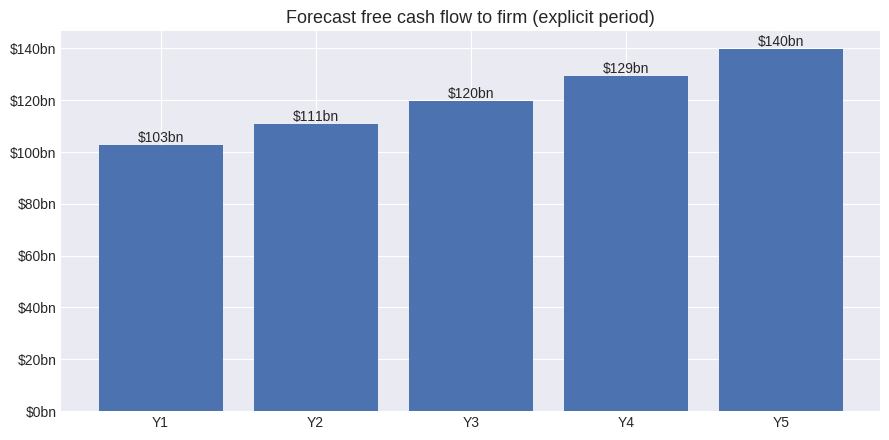

In [5]:
def dcf_fcff(fcff_0, wacc, growth_years, g_high, g_terminal, shares, net_debt):
    flows, fcff = [], fcff_0
    for t in range(1, growth_years + 1):
        fcff *= (1 + g_high)
        flows.append(fcff)
    pv = sum(cf / (1 + wacc) ** t for t, cf in enumerate(flows, 1))
    tv = flows[-1] * (1 + g_terminal) / (wacc - g_terminal)
    pv_tv = tv / (1 + wacc) ** growth_years
    ev = pv + pv_tv
    equity_value = ev - net_debt
    return dict(flows=flows, ev=ev, pv_explicit=pv, pv_terminal=pv_tv,
                equity=equity_value, per_share=equity_value / shares)

net_debt = A["debt"] - A["cash"]
dcf = dcf_fcff(A["fcff_0"], wacc, growth_years=5, g_high=0.08,
               g_terminal=0.035, shares=A["shares_out"], net_debt=net_debt)

print(f"Enterprise value      : ${dcf['ev']/1000:,.1f}bn")
print(f"  of which terminal   : {dcf['pv_terminal']/dcf['ev']:.0%}")
print(f"Equity value          : ${dcf['equity']/1000:,.1f}bn")
print(f"DCF value per share   : ${dcf['per_share']:,.2f}")

fig, ax = plt.subplots()
yrs = [f"Y{t}" for t in range(1, 6)]
ax.bar(yrs, dcf["flows"], color="#4C72B0")
ax.set_title("Forecast free cash flow to firm (explicit period)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1000:.0f}bn"))
for i, v in enumerate(dcf["flows"]):
    ax.text(i, v, f"${v/1000:.0f}bn", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## 4. Relative valuation — trading multiples

Intrinsic models rest on forecasts; multiples anchor to what the market pays for comparable
companies *today*. We apply peer-median **P/E** and **EV/EBITDA** multiples to ExampleTech's own
earnings and EBITDA.


In [6]:
peers = pd.DataFrame({
    "company": ["PeerA", "PeerB", "PeerC", "PeerD"],
    "pe":        [28.0, 24.5, 31.2, 26.8],
    "ev_ebitda": [19.0, 17.5, 21.0, 18.2],
})
pe_med  = peers.pe.median()
ev_med  = peers.ev_ebitda.median()

val_pe        = pe_med * A["eps_ttm"]
implied_ev    = ev_med * A["ebitda"]
val_evebitda  = (implied_ev - net_debt) / A["shares_out"]

print(peers.to_string(index=False))
print(f"\nPeer median P/E       : {pe_med:.1f}x  ->  ${val_pe:,.2f} / share")
print(f"Peer median EV/EBITDA : {ev_med:.1f}x  ->  ${val_evebitda:,.2f} / share")

company   pe  ev_ebitda
  PeerA 28.0       19.0
  PeerB 24.5       17.5
  PeerC 31.2       21.0
  PeerD 26.8       18.2

Peer median P/E       : 27.4x  ->  $175.36 / share
Peer median EV/EBITDA : 18.6x  ->  $152.77 / share


## 5. Sensitivity analysis

Intrinsic value is highly sensitive to two assumptions: the **discount rate (WACC)** and the
**terminal growth rate**. The heatmap shows DCF value per share across a grid of both — essential
for understanding how fragile a point estimate really is.


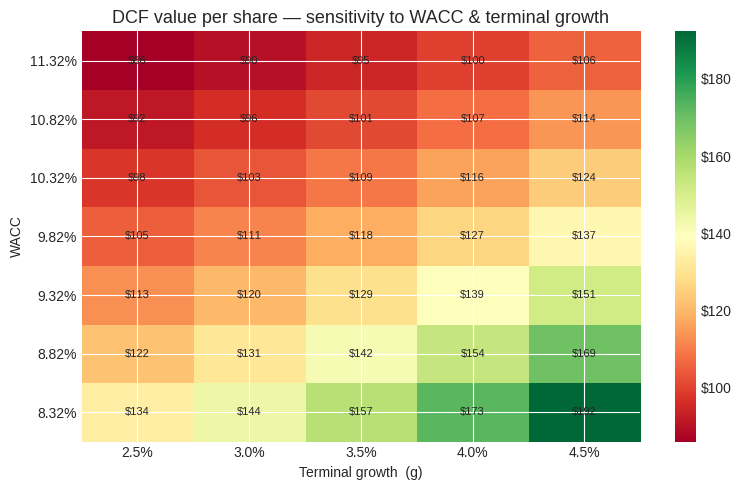

In [7]:
waccs = np.round(np.arange(wacc - 0.015, wacc + 0.016, 0.005), 4)
growths = np.round(np.arange(0.025, 0.046, 0.005), 4)

grid = np.zeros((len(waccs), len(growths)))
for i, w in enumerate(waccs):
    for j, g in enumerate(growths):
        grid[i, j] = dcf_fcff(A["fcff_0"], w, 5, 0.08, g,
                              A["shares_out"], net_debt)["per_share"]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(grid, cmap="RdYlGn", aspect="auto", origin="lower")
ax.set_xticks(range(len(growths))); ax.set_xticklabels([f"{g:.1%}" for g in growths])
ax.set_yticks(range(len(waccs)));   ax.set_yticklabels([f"{w:.2%}" for w in waccs])
ax.set_xlabel("Terminal growth  (g)"); ax.set_ylabel("WACC")
ax.set_title("DCF value per share — sensitivity to WACC & terminal growth")
for i in range(len(waccs)):
    for j in range(len(growths)):
        ax.text(j, i, f"${grid[i,j]:.0f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, format=mtick.FuncFormatter(lambda x, _: f"${x:.0f}"))
plt.tight_layout(); plt.show()

## 6. Summary — the football field

Every model produces a different number, and that's the point: each carries different assumptions
and biases. Laying them side by side against the current market price shows where the market sits
within the range of defensible values.


                   value_per_share vs_market
Gordon Growth DDM            16.03      -92%
Two-stage DDM                19.96      -89%
DCF (FCFF)                  118.33      -38%
Rel. — P/E                  175.36       -8%
Rel. — EV/EBITDA            152.77      -20%


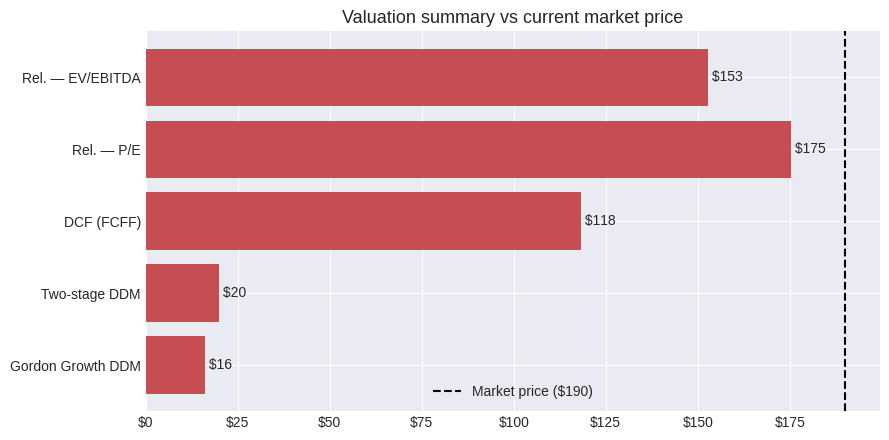

In [8]:
results = {
    "Gordon Growth DDM": p_gordon,
    "Two-stage DDM":     p_two_stage,
    "DCF (FCFF)":        dcf["per_share"],
    "Rel. — P/E":        val_pe,
    "Rel. — EV/EBITDA":  val_evebitda,
}
summary = pd.DataFrame({"value_per_share": results}).round(2)
summary["vs_market"] = (summary.value_per_share / A["price_now"] - 1)
print(summary.assign(vs_market=lambda d: d.vs_market.map("{:+.0%}".format)).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
names = list(results.keys()); vals = list(results.values())
colors = ["#55A868" if v >= A["price_now"] else "#C44E52" for v in vals]
ax.barh(names, vals, color=colors)
ax.axvline(A["price_now"], color="black", ls="--", lw=1.5,
           label=f"Market price (${A['price_now']:.0f})")
ax.set_title("Valuation summary vs current market price")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:.0f}"))
for i, v in enumerate(vals):
    ax.text(v, i, f" ${v:.0f}", va="center")
ax.legend(); plt.tight_layout(); plt.show()

### Reading the result

The spread between methods is itself the insight. DDM depends heavily on the dividend and the
tiny \(k_e - g\) denominator; DCF is dominated by the terminal value (note the % shown above);
multiples inherit whatever optimism or pessimism is currently priced into peers. A disciplined
valuation reports a **range** and states which assumptions drive it — not a single false-precision
number.

---

### Optional: live market data

Uncomment to pull real figures with `yfinance` and re-run the models on an actual ticker. Left off
by default so the notebook is fully reproducible offline.


In [9]:
# import yfinance as yf
# t = yf.Ticker("AAPL")
# info = t.info
# print({k: info.get(k) for k in ["currentPrice", "beta", "trailingEps", "sharesOutstanding"]})

*Prepared as coursework support for the Valuation subject, Master of Applied Finance (UNSW).
Educational only — not investment advice.*
